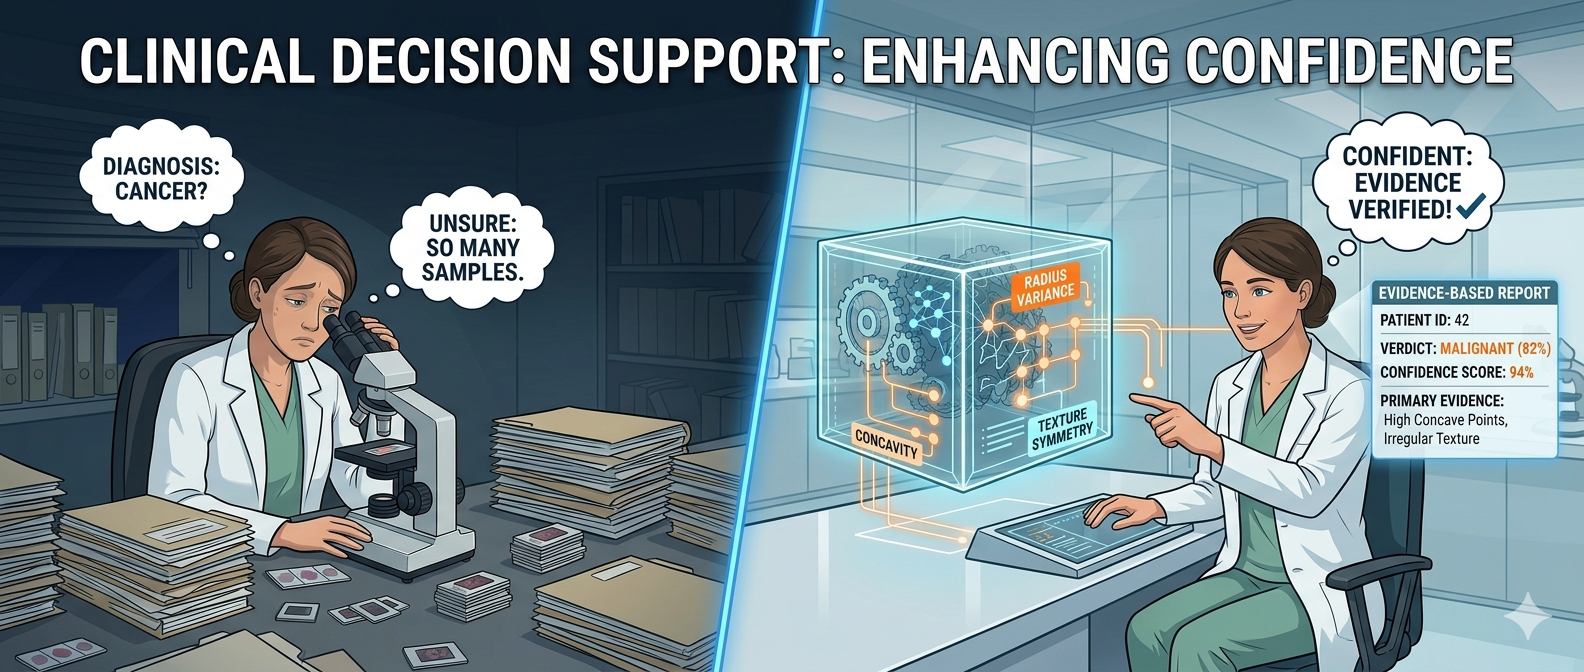

**Image generated by Google Gemini AI*


## Applied Machine Learning for Clinical Prediction
### PalmSpring · 2026

| | |
|---|---|
| **Created by** |*MSc.*  Berna Alemdag |
| **Advisors** | *Dr.* Gözde Kabay · *Prof.* Matthias Franzreb  |
| **Department** | BEBS |

</div>

---


# What is Machine Learning, really?

Imagine you are a doctor. Every day, patients come to you with blood test results, pathology results, tissue samples, and various clinical data, in addition to their individual history. You look at these numbers, compare them to thousands of cases you have seen before, and decide: is this benign or something we need to act on immediately?

Now, imagine a colleague who has studied not thousands, but hundreds of thousands of cases. They never get tired. They never have "bad days." And they can give you a second opinion in seconds.

That colleague is a Machine Learning model.

Machine Learning is not magic; it offers pattern recognition at scale. We show the computer many examples with known answers; it learns the patterns hidden in the numbers and then applies what it has learned to cases it has never seen before.

# What are we predicting today?
Today, we are working with a real clinical dataset collected at the University of Wisconsin.

They gathered data from 569 patients who had a suspicious breast mass. For each patient, a fine needle was used to collect a small tissue sample. Under a microscope, the cells were analyzed across 30 different features, such as:

Size: How large are the cell nuclei?

Symmetry: How irregular is their shape?

Texture: How rough is the cell boundary?

Each patient was then diagnosed by a pathologist:

🔴 Malignant (M) : Cancerous; requires immediate treatment/surgical removal

🟢 Benign (B) : Non-cancerous; no immediate danger, follow up.

Our goal today: To train a machine learning model that can analyze those 30 measurements and predict the correct diagnosis with high accuracy.


---

## The Dataset

We work with the **Wisconsin Breast Cancer Diagnostic (WBCD) dataset**,
first described by Street, Wolberg & Mangasarian (1993)
and hosted by the UCI Machine Learning Repository.

| Property | Detail |
|----------|--------|
| Samples | 569 patients |
| Features | 30 continuous measurements |
| Feature source | Digitised FNA images - cell nucleus morphology |
| Target | Binary: Malignant (M) · Benign (B) |
| Missing values | None |

Each of the 30 features describes one of ten nuclear characteristics
(radius, texture, perimeter, area, smoothness, compactness, concavity,
concave points, symmetry, fractal dimension), computed as the **mean**,
**standard error**, and **worst** value across all cell nuclei in the image.

---

## Workshop Roadmap

| Block | Topic | Role |
|-------|-------|------|
| 0 | Environment setup | Task |
| 1 | Data acquisition from UCI | Task |
| 2 | Class distribution analysis | Task |
| 3 | Correlation heatmap and feature reduction | Task |
| 4 | Random forest model development - Train/test splitting  | Demonstration |
| 5 | Different split and tree number comparison | Task |
| 6 | 5-Fold cross-validation (5-CV) | Demonstration |
| 7 | Stability analysis - 3-Fold, 5-Fold vs 7-Fold CV | Task |
| 8 | SHAP explainability analysis | Demonstration |
| 9 | Save the model| Demonstration |
| 10 | Live prediction of new patient diagnosis | Task |

---

> ⚠️ **Ethical declaration:** All analyses conducted here are for educational
> purposes exclusively. No output constitutes clinical advice.
> Deployment of any diagnostic ML model requires prospective clinical validation,
> regulatory clearance, and institutional ethics approval.


---
## Block 0 :Environment Setup

A Python library is a curated collection of pre-built functions and algorithms
maintained by the open-source scientific community.
Rather than implementing numerical routines from scratch,
we load battle-tested implementations that the research community has validated over decades.

| Library | Role in this workshop |
|---------|----------------------|
| `numpy` | Vectorised numerical computation - the backbone of scientific Python |
| `pandas` | Tabular data structures and manipulation |
| `matplotlib` | Core plotting engine |
| `seaborn` | Statistical visualisation built on matplotlib |
| `scikit-learn` | Reference ML toolkit: preprocessing, estimators, evaluation |
| `shap` | Model-agnostic explainability via Shapley values |
| `ucimlrepo` | Official UCI repository API client |

The cell below installs all required packages and imports `numpy` as a worked example.
Study the pattern - installation followed by import - before completing the task.

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn shap ucimlrepo --quiet

import numpy as np

print(f'numpy {np.__version__} — ready.')

---
### ✏️ Task 1 : Import the Remaining Libraries

**What to do:** Write one `import` statement for each library listed below.
Follow the alias convention exactly , these abbreviations are the universal standard
across the scientific Python ecosystem.

**Step by step:**
1. On line 3 - import `pandas` with alias `pd`
2. On line 4 - import `matplotlib.pyplot` with alias `plt`
3. On line 5 - import `seaborn` with alias `sns`
4. Run the cell - you should see three version numbers printed without any error

The remaining lines (sklearn, shap, joblib) are pre-written do not modify them.

In [ ]:
# ── Write your three import statements in the space below ────────────────

# ← line 3: import pandas with alias pd
# ← line 4: import matplotlib.pyplot with alias plt
# ← line 5: import seaborn with alias sns



# ── Pre-written — run as-is ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline          # ← used to prevent CV data leakage
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Verification ──────────────────────────────────────────────────────────
print(f'pandas   {pd.__version__}')
print('scikit-learn : loaded')
print('shap         : loaded')
print('All libraries ready. ✓')


---
## Block 1 : Data Acquisition from the UCI Machine Learning Database

The UCI Machine Learning Repository provides programmatic access
to its datasets via the `ucimlrepo` Python client  installed in Block 0.
This approach is preferable to manual downloading:
it is reproducible, version-controlled, and guarantees the canonical dataset.

Once fetched, the data is partitioned into two objects:

| Object | Shape | Contents |
|--------|-------|----------|
| `X` | (569 × 30) | Feature matrix : 30 morphological measurements per patient |
| `y` | (569 × 1) | Target vector : Diagnostic label: M (Malignant) or B (Benign) |

---
### ✏️ Task 1 : Fetch the Dataset Directly from UCI

**Step 1.** Open the official dataset page in a new browser tab:
> 👉 https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

**Step 2.** Locate the button labelled **'Import in Python'**
near the top-right of the dataset description. Click it.

**Step 3.** A modal window will appear containing a short code snippet.
Click the **copy icon** next to the code.

**Step 4.** Return to this notebook. In the cell below,
replace the comment `# ← paste breast cancer dataset code here` with the code you copied.

**Step 5.** Below the pasted snippet, uncomment the three lines
that assign `X`, `y`, and `y_series`. Then run the cell.

**Step 6.** Read the printed output and confirm:
569 samples, 30 features, classes [B, M], 0 missing values.

In [ ]:
# ── Step 4: Paste the UCI code snippet here ──────────────────────────────

# ← paste breast cancer dataset code here



# ── Step 5: Uncomment these three lines after pasting ─────────────────────
#X = breast_cancer_wisconsin_diagnostic.data.features   # 30-column feature matrix
#y = breast_cancer_wisconsin_diagnostic.data.targets    # diagnosis labels
#y_series = y.iloc[:, 0]                 # flatten to 1-D Series



# ── Step 6: Verification — run after completing steps above ───────────────
print(f'Feature matrix X : {X.shape[0]} samples × {X.shape[1]} features')
print(f'Target vector  y : {y_series.shape[0]} labels')
print(f'Classes          : {sorted(y_series.unique())}')
print(f'Missing values   : {X.isnull().sum().sum()}')
print()
X.head(3)

# Block 2 :Class Distribution Analysis

Before constructing any predictive model, we must characterise the class balance of the target variable.

An imbalanced dataset can mislead evaluation: a trivial classifier that always predicts the majority class achieves deceptively high accuracy while providing zero discriminative utility. This is the accuracy paradox, and it motivates the use of class-specific metrics: Precision, Recall, and F1-score introduced in Block 4.

The chart below visualises the sample count and proportion for each diagnostic class.

In [ ]:
counts = y_series.value_counts()

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
bars = ax.bar(
    ['Malignant (M)', 'Benign (B)'],
    [counts['M'], counts['B']],
    color=['#C0392B', '#1A7A4A'],
    width=0.45, alpha=0.72, edgecolor='white'
)
for bar, count in zip(bars, [counts['M'], counts['B']]):
    pct = count / len(y_series) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4,
            f'{count}  ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9)

majority_acc = round(counts['B'] / len(y_series) * 100, 1)
ax.set_title('Class Distribution — Wisconsin Breast Cancer Dataset',
             fontsize=10, pad=10)
ax.set_ylabel('Sample count', fontsize=9)
ax.set_ylim(0, counts.max() * 1.25)
ax.text(0.98, 0.97,
        f'Majority-class baseline: {majority_acc}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        color='#555555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5',
                  edgecolor='#cccccc', alpha=0.8))
sns.despine()
plt.tight_layout()
plt.savefig('block2_class_distribution.png', dpi=500, bbox_inches='tight')
plt.show()

# ✏️ Task 2: Reproduce the Chart with Your Own Colour Scheme

**Step 1.** On the my_colors line replace the two colour values with any two colours of your choice. You may use named colours (e.g. 'steelblue') or hex codes (e.g. '#2E86AB').

**Step 2.** On the my_title line insert new title name.

**Step 3.** Run the cell and confirm the chart updates correctly.

💡 Python named colour reference: https://matplotlib.org/stable/gallery/color/named_colors.html

In [ ]:
my_colors = ['steelblue', 'darkorange']      # ← replace with your two chosen colours
my_title  = 'Class Distribution — Your Name' # ← insert your name

counts = y_series.value_counts()

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
bars = ax.bar(
    ['Malignant (M)', 'Benign (B)'],
    [counts['M'], counts['B']],
    color=my_colors,   # ← applied here
    width=0.45, alpha=0.72, edgecolor='white'
)
for bar, count in zip(bars, [counts['M'], counts['B']]):
    pct = count / len(y_series) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4,
            f'{count}  ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_title(my_title, fontsize=10, pad=10)
ax.set_ylabel('Sample count', fontsize=9)
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig('block2_task_chart.png', dpi=500, bbox_inches='tight')
plt.show()

---
## Block 3: Correlation Analysis and Feature Reduction

### 3.1: Multicollinearity

When two features are highly correlated, they encode largely redundant information.
For example, cell *radius*, *perimeter*, and *area* are geometrically coupled:
perimeter scales linearly with radius, and area with its square.
Retaining all three adds no predictive signal but increases model complexity
and can destabilise coefficient estimation in linear models.

The **Pearson correlation matrix** encodes the linear relationship
between every pair of features. Correlation values are printed directly
inside each cell for precise reference.

| Colour | Interpretation |
|--------|----------------|
| Dark red (r → +1) | Strong positive linear correlation |
| Dark blue (r → −1) | Strong negative linear correlation |
| White (r ≈ 0) | No linear relationship |

In [ ]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(18, 15), dpi=600)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 4.5},
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.15, linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.6},
    ax=ax
)
ax.set_title(
    'Pairwise Pearson Correlation',
    fontsize=11, pad=14
)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.savefig('block3_heatmap_full.png', dpi=600, bbox_inches='tight')
plt.show()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
top10 = (
    upper.stack().reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
    .assign(abs_r=lambda d: d['r'].abs())
    .sort_values('abs_r', ascending=False)
    .drop(columns='abs_r').head(10)
)
print('Ten most correlated pairs:')
print(top10.to_string(index=False))

# ✏️ Task 3 :Apply the Correlation Filter (τ = 0.90)

The heatmap above reveals clusters of features with correlation values above 0.9. Your task is to remove those features and verify the result visually.

**Step 1.** The threshold is fixed at 0.90.

**Step 2.** Read through the four-step algorithm in the code comments. Each step is labelled. Run the cell.

**Step 3.** Check the printed output: how many features were removed, and which feature names appear in the list?

**Step 4.** Inspect the second heatmap confirm that no remaining feature pair displays a value above 0.9.

**Step 5.** Answer the two questions at the bottom as code comments.

In [ ]:
threshold =      # enter threshold (0.90)

# Step 1 — compute absolute pairwise correlations
corr_abs  = X.corr().abs()

# Step 2 — retain only the upper triangle to avoid counting each pair twice
upper_tri = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# Step 3 — identify features whose correlation with any other exceeds the threshold
to_drop   = [col for col in upper_tri.columns
             if any(upper_tri[col] > threshold)]

# Step 4 — drop identified features; X_reduced is used in all subsequent blocks
X_reduced = X.drop(columns=to_drop)

print(f'Threshold τ        : {threshold}')
print(f'Original features  : {X.shape[1]}')
print(f'Removed            : {len(to_drop)}  →  {to_drop}')
print(f'Retained           : {X_reduced.shape[1]}')
print()

fig, ax = plt.subplots(figsize=(13, 11), dpi=600)
sns.heatmap(
    X_reduced.corr(),
    annot=True,
    fmt='.1f',
    annot_kws={'size': 5.5},
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.2, linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.6},
    ax=ax
)
ax.set_title(
    f'Correlation Matrix After Reduction  '
    f'(τ = {threshold}  ·  {X_reduced.shape[1]} features retained)',
    fontsize=10, pad=12
)
ax.tick_params(axis='x', labelsize=7.5, rotation=45)
ax.tick_params(axis='y', labelsize=7.5, rotation=0)
plt.tight_layout()
plt.savefig('block3_heatmap_reduced.png', dpi=600, bbox_inches='tight')
plt.show()

# ── Answer as comments ────────────────────────────────────────────────────
# Does any cell in the reduced heatmap show a value above 0.9?
# How many features were there originally, how many remain after feature reduction?


# Block 4: ML development and evulation : Random forest classifier

You have reached the core of this workshop. Everything before this point: loading data, checking class balance, and removing redundant features was preparation for this moment. We now train a ML model on real patient data and measure how well it predicts a diagnosis it has never seen before.

# 4.1 - What is a Random Forest?

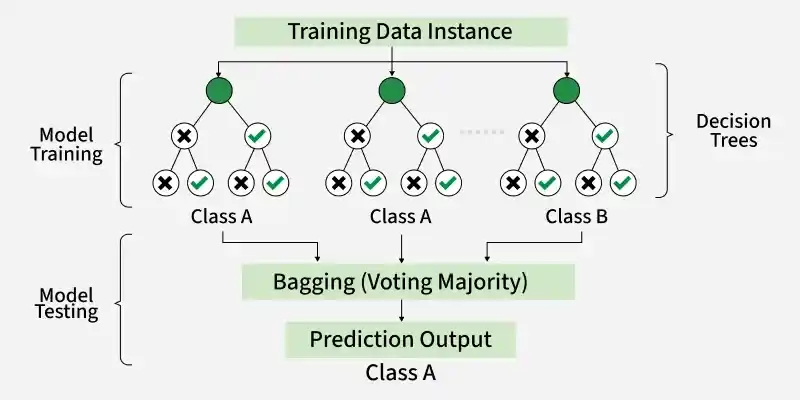

**https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/*

# How Random Forest Works?

Look at the diagram above.
Each green circle at the top is one decision tree. The forest trains many of these trees in our case, 100.

Every tree looks at the same patient data but asks slightly different questions and focuses on different features. Because of this, each tree reaches its own conclusion; some predict Class A, some predict Class B.

Once all trees have voted, the forest applies Bagging (Voting Majority), it simply counts the votes and goes with the most popular answer.

In the diagram: 2 trees voted Class A, 1 tree voted Class B → final prediction: Class A.

#### The key parameter: `n_estimators`

| `n_estimators` | Effect |
|----------------|--------|
| 10 | Few trees - fast, but higher variance (unstable predictions) |
| 100 | Standard default - good balance of performance and speed |
| 500 | Many trees - more stable, but slower to train |

More trees generally improve stability up to a point,
after which additional trees yield diminishing returns.

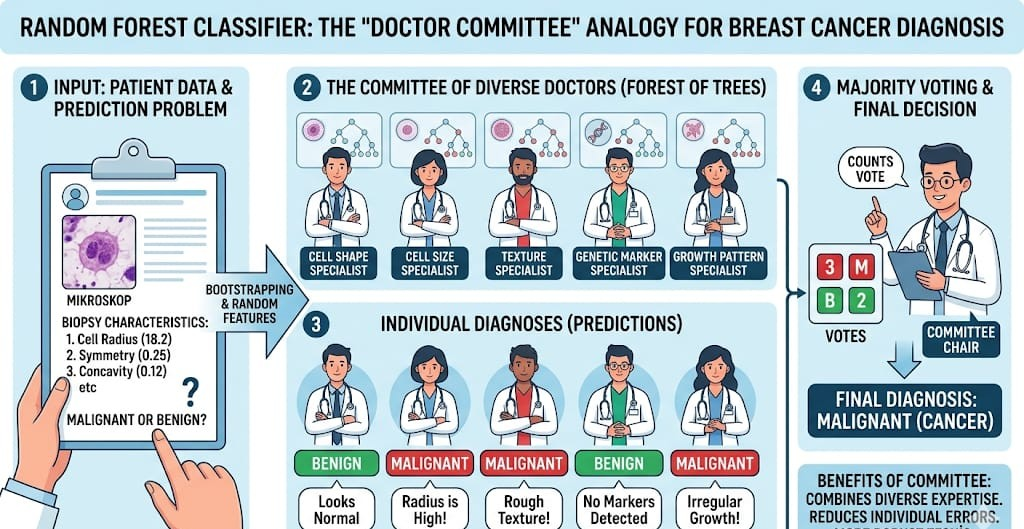

**Image generated by Google Gemini AI*

---
### 4.2 - Preparing the Data: Labels, Scaling, and Train/Test Split

Before training, three preprocessing steps are required.

**Label encoding**: The target variable contains strings (`'M'`, `'B'`).
ML models require numerical targets: we encode **M → 1** and **B → 0**.

**Train/test split**: We partition the data so the model is evaluated
on patients it has **never seen during training**.
We use an 80/20 split: 80% for training, 20% for testing.
The `stratify` argument preserves the Malignant/Benign ratio in both partitions.

**Normalization**: Each feature is rescaled to zero mean and unit variance.
Random Forest does not strictly require this, but applying it consistently
ensures clean, comparable feature scales throughout the pipeline.



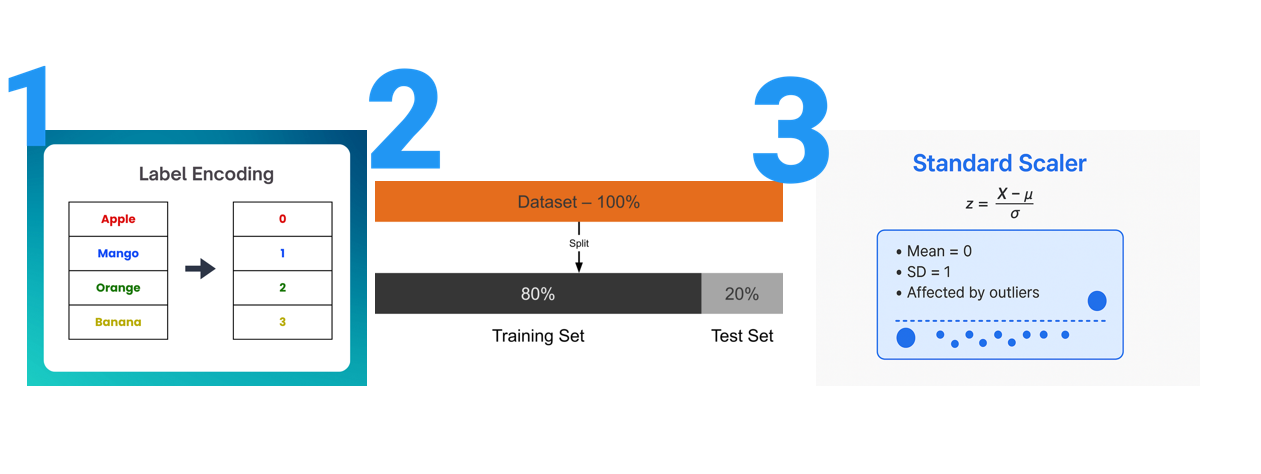

In [ ]:
# Step 1 — Convert diagnosis labels to numbers: M → 1, B → 0
y_encoded = (y_series == 'M').astype(int).values

# Step 2 — Data spliting train/test (80/20 %)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_reduced, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Step 3 — Feature scaling via normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # learn μ, σ from train
X_test  = scaler.transform(X_test_raw)        # apply train's μ, σ to test

print(f'Training : {len(X_train)} patients')
print(f'Testing  : {len(X_test)} patients')



# 4.3 - Training the Model

We train a Random Forest with 100 trees on the training set. The .fit() call is where the learning happens: the model reads all 455 training patients, builds 100 decision trees, and learns which feature patterns are associated with each diagnosis.

In [ ]:
# Train the Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = rf.predict(X_test)

print('Random Forest trained on 80% of patients. ✓')
print(f'Now evaluating on the remaining {X_test.shape[0]} patients the model has never seen...')

---
## 4.4 - Model Evaluation

We evaluate the model on the **test set** the 20% of patients
the model did not see during training.

Four metrics are reported. Each captures a different aspect of performance:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **Accuracy** | (TP + TN) / N | Of all test patients, what fraction were classified correctly? |
| **Precision** | TP / (TP + FP) | Of all patients predicted Malignant, how many truly were? |
| **Recall** | TP / (TP + FN) | Of all truly Malignant patients, how many did the model catch? |
| **F1-score** | 2·P·R / (P+R) | Harmonic mean of Precision and Recall |

**TP** = True Positive · **TN** = True Negative · **FP** = False Positive · **FN** = False Negative

---

#### Why Recall is the primary metric in cancer screening?

A **False Negative** :Predicting Benign when the patient is Malignant
means the patient leaves without treatment. The consequences can be fatal.

A **False Positive** : predicting Malignant when the patient is Benign
triggers unnecessary additional tests. Costly and stressful, but survivable.


---


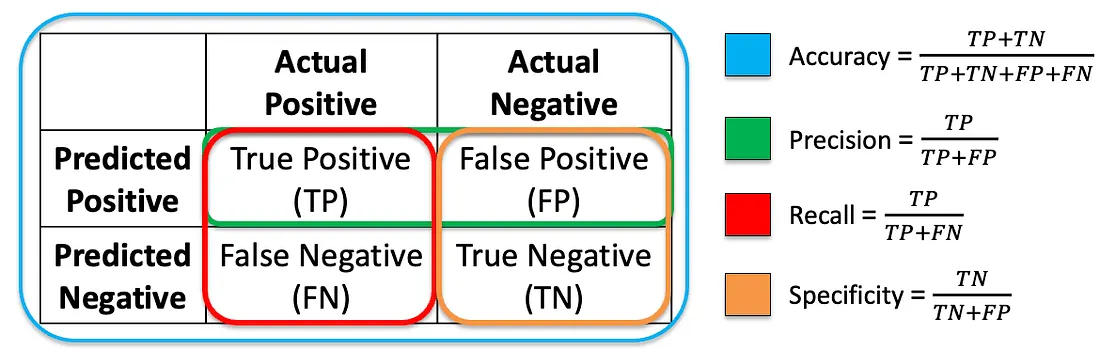

**https://medium.com/@lmpo/mastering-classification-metrics-a-deep-dive-into-accuracy-precision-recall-f1-score-and-f8caaf669bf0*

In [ ]:
# Classification report
report = classification_report(
    y_test, y_pred,
    target_names=['Benign (0)', 'Malignant (1)'],
    digits=4,
    output_dict=True
)

metrics = ['precision', 'recall', 'f1-score']
for label in ['Benign (0)', 'Malignant (1)']:
    row = report[label]
    print(f"{label:<16}", end='')
    for m in metrics:
        print(f"  {m}: {row[m]:.4f}", end='')
    print()

print()
acc = report['accuracy']
print(f"Accuracy : {acc:.4f}")

# Metric bar chart and confusion matrix
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_fns   = [
    accuracy_score,
    lambda y, p: precision_score(y, p),
    lambda y, p: recall_score(y, p),
    lambda y, p: f1_score(y, p),
]
scores_80 = [fn(y_test, y_pred) for fn in metric_fns]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=600)

ax = axes[0]
bars = ax.bar(metric_names, scores_80,
              color='#E07B54', alpha=0.72, edgecolor='white', width=0.45)
for bar, val in zip(bars, scores_80):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, color='#333333')
ax.set_ylim(0.80, 1.04)
ax.set_ylabel('Score', fontsize=9)
ax.set_title('Random Forest - 80/20 % (Train/Test)', fontsize=12, pad=8)
ax.axhline(0.90, color='#aaaaaa', linewidth=0.7, linestyle='--')
ax.tick_params(labelsize=8)
sns.despine(ax=ax)

ax2 = axes[1]
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Benign', 'Malignant']
).plot(ax=ax2, cmap='Oranges', colorbar=False)
ax2.set_title('Confusion Matrix — 80/20', fontsize=9, pad=8)

plt.suptitle('Random Forest - 80/20 % (Train/Test)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('rf_80_20_evaluation.png', dpi=600, bbox_inches='tight')
plt.show()

---
### ✏️ Task 4a : Experiment with Different Splits and Tree Counts

You have seen the model trained with 80/20 split and 100 trees.
Now you will change **both parameters** and observe how performance responds.

**Why does this matter?**
- **The effect of test split:** A smaller training set means the model learns from fewer patients. Does it suffer?
- **The effect of number of trees:** Fewer trees means more variance; does Recall drop? More trees mean higher computational cost; is it worth it?

---

**Step 1 - Investigate the effect of test split: ** Set the first line `test_size = 0.30` and the second line as `n_estimators = 100`.
Run it.
Read the printed metrics carefully.


**Step 2 - The effect of number of trees** Set the first line `test_size = 0.30` and the second line as `n_estimators = 1000`.
Run it.
Read the printed metrics carefully.


**Step 3: Draw comparison chart:**
The comparison chart draws all two configurations
(80/20 + 100 trees, 70/30 + 100 trees, 70/30 + 1000 trees) side by side automatically.

In [ ]:
# ── Step 1: Run at 70/30 + 100 trees

test_size_exp    =     # ← Step 1: leave as 0.30
n_estimators_exp =     # ← Step 1: leave as 100

# Split first, then scale (fit on training portion only)
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_reduced, y_encoded,
    test_size=test_size_exp, random_state=42, stratify=y_encoded
)
scaler_exp = StandardScaler()
X_tr = scaler_exp.fit_transform(X_tr_raw)
X_te = scaler_exp.transform(X_te_raw)

rf_exp = RandomForestClassifier(n_estimators=n_estimators_exp, random_state=42)
rf_exp.fit(X_tr, y_tr)
y_pred_exp = rf_exp.predict(X_te)

split_lbl = f'{100-int(test_size_exp*100)}/{int(test_size_exp*100)}'
print(f'Split          : {split_lbl}')
print(f'Trees          : {n_estimators_exp}')
print(f'Training set   : {X_tr.shape[0]} patients')
print(f'Test set       : {X_te.shape[0]} patients')
print()
print(f'Accuracy       : {accuracy_score(y_te, y_pred_exp):.4f}')
print(f'Precision      : {precision_score(y_te, y_pred_exp):.4f}')
print(f'Recall (M)     : {recall_score(y_te, y_pred_exp):.4f}')
print(f'F1-score       : {f1_score(y_te, y_pred_exp):.4f}')


In [ ]:
# ── Step 2: Run at 70/30 + 1000 trees

test_size_exp    =     # ← Step 2: leave as 0.30
n_estimators_exp =     # ← Step 2: leave as 1000

# Split first, then scale
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_reduced, y_encoded,
    test_size=test_size_exp, random_state=42, stratify=y_encoded
)
scaler_exp = StandardScaler()
X_tr = scaler_exp.fit_transform(X_tr_raw)
X_te = scaler_exp.transform(X_te_raw)

rf_exp = RandomForestClassifier(n_estimators=n_estimators_exp, random_state=42)
rf_exp.fit(X_tr, y_tr)
y_pred_exp = rf_exp.predict(X_te)

split_lbl = f'{100-int(test_size_exp*100)}/{int(test_size_exp*100)}'
print(f'Split          : {split_lbl}')
print(f'Trees          : {n_estimators_exp}')
print(f'Training set   : {X_tr.shape[0]} patients')
print(f'Test set       : {X_te.shape[0]} patients')
print()
print(f'Accuracy       : {accuracy_score(y_te, y_pred_exp):.4f}')
print(f'Precision      : {precision_score(y_te, y_pred_exp):.4f}')
print(f'Recall (M)     : {recall_score(y_te, y_pred_exp):.4f}')
print(f'F1-score       : {f1_score(y_te, y_pred_exp):.4f}')

In [ ]:
# ── Step 3: Comparison chart all two  configurations ──────────────────
configs = [
    ('80/20 · 100 trees', , ), # ← Enter test size and tree number
    ('70/30 · 100 trees',  ,  ),# ← Enter test size and tree number
    ('70/30 · 10 trees',  ,  ),# ← Enter test size and tree number
]
colors = ['#E07B54', '#5B8DB8', '#6BAE6E']
labels = ['Accuracy', 'Precision', 'Recall', 'F1']

def get_rf_scores(ts, n_est):
    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X_reduced, y_encoded, test_size=ts, random_state=42, stratify=y_encoded)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr_raw)
    Xte = sc.transform(Xte_raw)
    m = RandomForestClassifier(n_estimators=n_est, random_state=42).fit(Xtr, ytr)
    p = m.predict(Xte)
    return [round(fn(yte, p), 4) for fn in [
        accuracy_score,
        lambda y, pp: precision_score(y, pp),
        lambda y, pp: recall_score(y, pp),
        lambda y, pp: f1_score(y, pp)
    ]]

all_scores = {lbl: get_rf_scores(ts, n) for lbl, ts, n in configs}

x = np.arange(len(labels))
w = 0.22
offsets = [-w, 0, w]

fig, ax = plt.subplots(figsize=(9, 4), dpi=600)
for (lbl, scores), offset, color in zip(all_scores.items(), offsets, colors):
    bars = ax.bar(x + offset, scores, w, label=lbl,
                  color=color, alpha=0.75, edgecolor='white')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_ylim(0.78, 1.06)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score', fontsize=9)
ax.set_title('Random Forest - Effect of Split Ratio and Tree Count', fontsize=10, pad=10)
ax.legend(fontsize=8, framealpha=0.4)
ax.axhline(0.90, color='#aaaaaa', linewidth=0.7, linestyle='--')
sns.despine()
plt.tight_layout()
plt.savefig('task4a_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


---
### 4.5- Cross-Validation (CV)

The 80/20 model performance result we obtained above is from a **single random experiment**.
Meaning that, the reliability of the model is coincidental, as the data partitioning is random.

An unusually easy or unusually hard test partition can make the model performance look better or worse than it actually is.

**K-fold cross-validation** removes this dependency:

1. Divide the full dataset into **K equal groups** (folds)
2. For each fold *k*: train on the other K-1 folds, evaluate on fold *k*
3. Repeat the validation process K times, so that every patient is tested at each fold **exactly once**
4. Report the **mean accuracy** (μ) and **standard deviation** (σ) across all K scores.

A low σ means the model performs consistently regardless of which patients
end up in the test fold, a necessary condition for trusting the result.

A low σ means the model performs consistently regardless of which patients
end up in the test fold a necessary condition for trusting the result.

| σ value | Interpretation |
|---------|----------------|
| σ < 0.02 | Highly stable |
| 0.02 – 0.04 | Acceptable variation |
| σ > 0.05 | Unstable performance is sensitive to data composition |



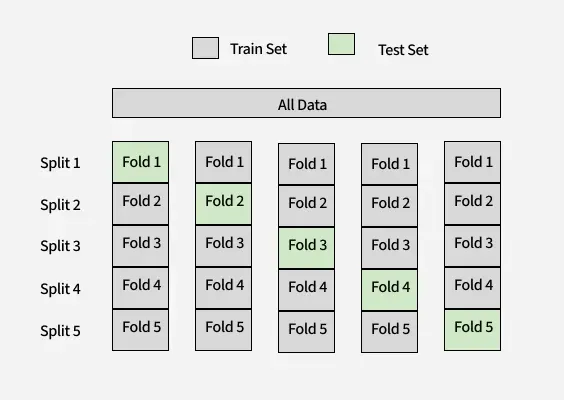

**https://www.geeksforgeeks.org/machine-learning/k-fold-cross-validation-in-machine-learning/*

In [ ]:
# 5 fold cross validation
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(n_estimators=100, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv5 = cross_val_score(rf_pipe, X_reduced, y_encoded, cv=skf, scoring='accuracy')

print('5-Fold Stratified Cross-Validation — Random Forest')
print('─' * 50)
print(f'Fold scores : {[round(s, 4) for s in scores_cv5]}')
print(f'Mean  (μ)  : {scores_cv5.mean():.4f}')
print(f'Std   (σ)  : {scores_cv5.std():.4f}')
stab = '✓ Stable' if scores_cv5.std() < 0.03 else '⚠ Variable'
print(f'Stability  : {stab}')


In [ ]:
# Fold-by-fold chart and mean ± σ bar
fold_labels = [f'Fold {i+1}' for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=600)

# Left: fold-by-fold line
ax = axes[0]
ax.plot(fold_labels, scores_cv5, marker='o', markersize=5,
        linewidth=1.2, color='#E07B54', alpha=0.85)
ax.axhline(scores_cv5.mean(), color='#E07B54', linewidth=0.8,
           linestyle='--', alpha=0.5, label=f'Mean = {scores_cv5.mean():.3f}')
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Accuracy', fontsize=9)
ax.set_title('Fold-by-Fold Accuracy — 5-Fold CV', fontsize=9, pad=8)
ax.legend(fontsize=8, framealpha=0.4)
ax.tick_params(labelsize=8)
sns.despine(ax=ax)

# Right: mean ± σ
ax2 = axes[1]
ax2.bar(['Random Forest'], [scores_cv5.mean()],
        color='#E07B54', alpha=0.72, edgecolor='white', width=0.3)
ax2.errorbar(['Random Forest'], [scores_cv5.mean()], yerr=[scores_cv5.std()],
             fmt='none', ecolor='#555555', elinewidth=1.5, capsize=8)
ax2.text(0, scores_cv5.mean() + scores_cv5.std() + 0.006,
         f'μ = {scores_cv5.mean():.4f}\nσ = {scores_cv5.std():.4f}',
         ha='center', va='bottom', fontsize=9, color='#333333')
ax2.set_ylim(0.88, 1.06)
ax2.set_ylabel('Accuracy', fontsize=9)
ax2.set_title('Mean ± Std — 5-Fold CV', fontsize=9, pad=8)
ax2.tick_params(labelsize=8)
sns.despine(ax=ax2)

plt.suptitle('5-Fold Stratified Cross-Validation - Random Forest', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('rf_5fold_cv.png', dpi=600, bbox_inches='tight')
plt.show()

---
### ✏️ Task 4b - Compare 3-fold CV and 7-fold CV

You have seen the model evaluated with 5-fold CV.
Now test whether the number of folds changes the stability of the result.

**Why does K matter?**

| K | Training per fold | Test per fold | Consequence |
|---|-------------------|---------------|-------------|
| Small (3) | Smaller ≈ 67% | Larger ≈ 33% | Less training data → possible underestimation |
| Large (7) | Larger ≈ 86% | Smaller ≈ 14% | Smaller test folds → more variable individual scores |

Neither is universally better — but comparing them tells us
how sensitive the estimate is to the choice of K.

---

**Step 1.** The cell is set to `my_k = 3`. Run it.
Write the μ and σ values in the results table below.

**Step 2.** Change `my_k = 7` and run again.
Write the new μ and σ in the table.

**Step 3.** The comparison chart draws K=3, K=5, and K=7 side by side automatically.
Study both the fold-by-fold scores and the error bars.

**Step 4.** Complete the table and answer the two questions.

In [ ]:
my_k =    # ← Step 1: 3 kfold

skf_k  = StratifiedKFold(n_splits=my_k, shuffle=True, random_state=42)
scores = cross_val_score(rf_pipe, X_reduced, y_encoded, cv=skf_k, scoring='accuracy')

print(f'{my_k}-Fold Stratified Cross-Validation — Random Forest')
print('─' * 50)
print(f'Fold scores : {[round(s, 4) for s in scores]}')
print(f'Mean  (μ)  : {scores.mean():.4f}')
print(f'Std   (σ)  : {scores.std():.4f}')
sigma = scores.std()
if sigma < 0.02:
    stab = '✓ Highly stable'
elif sigma <= 0.04:
    stab = '~ Acceptable variation'
else:
    stab = '⚠ Unstable — sensitive to data composition'
print(f'Stability  : {stab}')


In [ ]:
my_k =    # ← Step 2: change to 7

skf_k  = StratifiedKFold(n_splits=my_k, shuffle=True, random_state=42)
scores = cross_val_score(rf_pipe, X_reduced, y_encoded, cv=skf_k, scoring='accuracy')

print(f'{my_k}-Fold Stratified Cross-Validation — Random Forest')
print('─' * 50)
print(f'Fold scores : {[round(s, 4) for s in scores]}')
print(f'Mean  (μ)  : {scores.mean():.4f}')
print(f'Std   (σ)  : {scores.std():.4f}')
sigma = scores.std()
if sigma < 0.02:
    stab = '✓ Highly stable'
elif sigma <= 0.04:
    stab = '~ Acceptable variation'
else:
    stab = '⚠ Unstable — sensitive to data composition'
print(f'Stability  : {stab}')

In [ ]:
# ── Step 3: Comparison chart, K=3, K=5, K=7 ─────────────────────────────
cv_palette = {3: '#5B8DB8', 5: '#E07B54', 7: '#6BAE6E'}

def get_cv_scores(k):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    # Pipeline → scaler refits inside every fold → no leakage
    return cross_val_score(rf_pipe, X_reduced, y_encoded, cv=skf, scoring='accuracy')

cv_data = {k: get_cv_scores(k) for k in [3, 5, 7]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=600)

# Left: fold-by-fold lines for each K
ax = axes[0]
for k, scores in cv_data.items():
    fold_lbl = [f'F{i+1}' for i in range(k)]
    ax.plot(fold_lbl, scores, marker='o', markersize=5,
            linewidth=1.2, label=f'K={k}  μ={scores.mean():.3f}',
            color=cv_palette[k], alpha=0.85)
ax.set_ylim(0.86, 1.02)
ax.set_ylabel('Accuracy', fontsize=9)
ax.set_title('Fold-by-Fold Accuracy - K=3, 5, 7', fontsize=9, pad=8)
ax.legend(fontsize=8, framealpha=0.4)
ax.tick_params(labelsize=8)
sns.despine(ax=ax)

# Right: mean ± σ bars
ax2 = axes[1]
k_labels = [f'K={k}' for k in cv_data]
means    = [cv_data[k].mean() for k in cv_data]
stds     = [cv_data[k].std()  for k in cv_data]
colors   = [cv_palette[k] for k in cv_data]
bars     = ax2.bar(k_labels, means, color=colors, alpha=0.72,
                   edgecolor='white', width=0.38)
ax2.errorbar(k_labels, means, yerr=stds, fmt='none',
             ecolor='#555555', elinewidth=1.2, capsize=7)
for bar, mean, std in zip(bars, means, stds):
    ax2.text(bar.get_x() + bar.get_width()/2,
             mean + std + 0.005,
             f'μ={mean:.3f}\nσ={std:.3f}',
             ha='center', va='bottom', fontsize=8, color='#333333')
ax2.set_ylim(0.86, 1.08)
ax2.set_ylabel('Mean Accuracy ± σ', fontsize=9)
ax2.set_title('Stability Comparison - K=3, 5, 7', fontsize=9, pad=8)
ax2.tick_params(labelsize=8)
sns.despine(ax=ax2)

plt.suptitle('Cross-Validation Stability - Random Forest', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('task4b_cv_comparison.png', dpi=500, bbox_inches='tight')
plt.show()


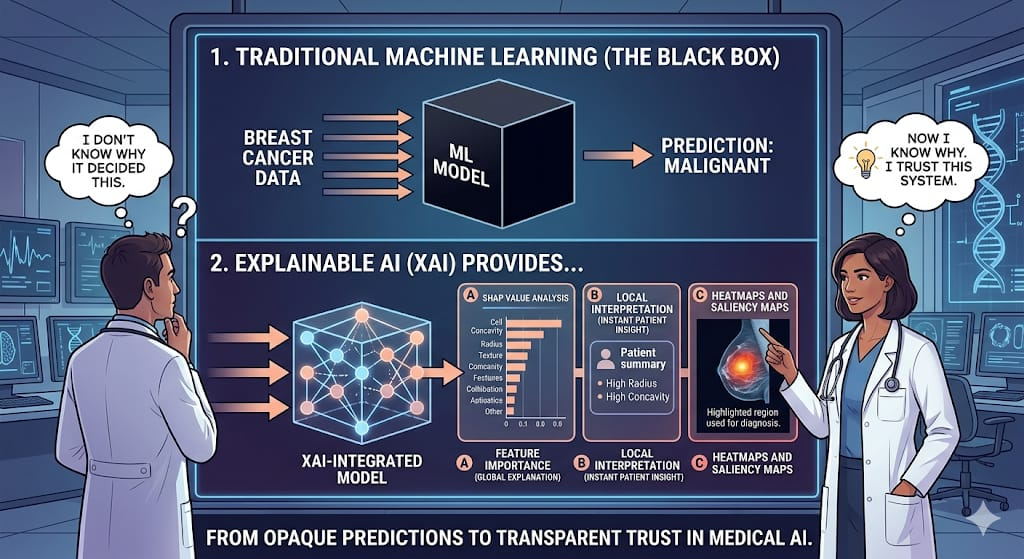

*Image generated by Google Gemini AI

---
## Block 5 - SHAP Explainability Analysis

### 5.1 - The Black-Box Problem

Our Random Forest achieves strong predictive performance.
But a high accuracy score alone does not tell us **why** the model makes each decision.

A clinician will not integrate a model into practice unless they can verify
that it is relying on features that make **biological sense**.
If the model is exploiting a spurious statistical pattern in the training data,
it may fail badly on new patient populations even while appearing accurate on the test set.

---

### 5.2 - Shapley Values

**SHAP (SHapley Additive exPlanations)** provides a theoretically grounded
framework for feature attribution, borrowed from cooperative game theory.

For any individual prediction, each feature receives a **Shapley value** φⱼ:

$$f(\mathbf{x}) = \phi_0 + \sum_{j=1}^{p} \phi_j$$

where φ₀ is the model's base rate (mean output across the training set),
and φⱼ is how much feature *j* shifted the prediction for this specific patient.

Key properties:
- **Local fidelity** :Values sum exactly to the model output for each patient
- **Consistency** : A  more important feature always receives a higher SHAP value
- **Nullity**: Unused features receive SHAP value zero

---

### 5.3 - Reading the Plots

**Bar chart (mean |SHAP|):** Global importance average magnitude across all patients.

**Beeswarm plot:** Each dot is one patient. Position on x-axis = SHAP value. Positive → pushes prediction toward Malignant. Negative → pushes toward Benign. Color = raw feature value (red = high, blue = low)

In [ ]:
X_shap = pd.DataFrame(
    scaler.transform(X_reduced),
    columns=X_reduced.columns
)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

# 3D array (569, 20, 2)
shap_m = shap_values[:, :, 1]

print(f'shap_m shape : {shap_m.shape}')   # (569, 20)
print(f'X_shap shape : {X_shap.shape}')   # (569, 20)
print(f'Match        : {shap_m.shape == X_shap.shape}')


**The Bar Chart Representation - Global Feature Importance Analysis:** First, we assess which features have the greatest impact on the target output by evaluating the magnitude of SHAP values.

In [ ]:
print('Mean |SHAP| global feature importance')
print()

shap.summary_plot(
    shap_m,
    X_shap,
    feature_names=X_shap.columns.tolist(),
    plot_type='bar',
    max_display=15,
    show=True
)

mean_shap = pd.Series(
    np.abs(shap_m).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print('Top 10 features by mean |SHAP|:')
for rank, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    print(f'  {rank:>2}. {feat:<38} {val:.4f}')

**The Beeswarm Representation:** Each dot represents one patient. Position on x-axis = SHAP value. Positive → pushes prediction toward Malignant. Negative → pushes toward Benign. Color = raw feature value (red = high, blue = low)

In [ ]:
print('Beeswarm — each point is one patient')
print('Right (positive SHAP) → pushes prediction toward Malignant')
print('Left  (negative SHAP) → pushes prediction toward Benign')
print()

shap.summary_plot(
    shap_m,
    X_shap,
    feature_names=X_shap.columns.tolist(),
    plot_type='dot',
    max_display=15,
    show=True)

---
## Block 6- Saving the Model

We trained a good model. Now we save it to disk so we can use it
later without training from scratch again.

Think of it like saving a Word document
next time you open it, everything is still there.

We save three files:

| File | What it contains |
|------|-----------------|
| `best_model_rf.pkl` | The trained model |
| `feature_scaler.pkl` | The scaling rules applied to the data |
| `feature_columns.pkl` | The list of features the model expects |

All three files are needed together.
Without the scaler, new patient data would be on a different scale.
Without the column list, features might arrive in the wrong order.

In [ ]:
joblib.dump(rf,                             'best_model_rf.pkl')
joblib.dump(scaler,                         'feature_scaler.pkl')
joblib.dump(X_reduced.columns.tolist(),     'feature_columns.pkl')

print('Serialised:')
print('  best_model_rf.pkl     — trained Random Forest')
print('  feature_scaler.pkl    — fitted StandardScaler')
print('  feature_columns.pkl   — ordered feature list')
print()
print('To reload in a future session:')
print("  model   = joblib.load('best_model_rf.pkl')")
print("  scaler  = joblib.load('feature_scaler.pkl')")
print("  columns = joblib.load('feature_columns.pkl')")

---
## Block 7- Live Patient Prediction: The Moment of Truth

This is what we have been building toward.

A real patient walked into a clinic with a suspicious breast mass.
A fine needle biopsy was performed, and 30 measurements were taken from the cell sample.
The pathologist's report is pending.

**Before the lab result arrives our model will make a prediction.**

---

You are now the data scientist supporting the clinical team.
Below are the patient's measurements. Fill in each value,
run the model, and record your prediction.

Then the instructor will reveal the true diagnosis.

---


# ✏️ Task 5 : Live prediction new patient diagnosis

### 🔬 Patient Record

The table below shows the patient's biopsy results.
You will copy each value into the code cell.

**Mean measurements** average across all cell nuclei in the image:

| Feature | Patient value | Typical benign range |
|---------|--------------|---------------------|
| `radius_mean` | 20.57 | 10 – 15 |
| `texture_mean` | 17.77 | 10 – 20 |
| `perimeter_mean` | 132.90 | 70 – 105 |
| `area_mean` | 1326.0 | 300 – 700 |
| `smoothness_mean` | 0.08474 | 0.07 – 0.10 |
| `compactness_mean` | 0.07864 | 0.03 – 0.10 |
| `concavity_mean` | 0.08690 | 0.01 – 0.08 |
| `concave_points_mean` | 0.07017 | 0.010 – 0.040 |
| `symmetry_mean` | 0.1812 | 0.14 – 0.20 |
| `fractal_dimension_mean` | 0.05667 | 0.05 – 0.07 |

**Standard error measurements** variability across nuclei:

| Feature | Patient value |
|---------|--------------|
| `radius_se` | 0.5435 |
| `texture_se` | 0.7339 |
| `perimeter_se` | 3.398 |
| `area_se` | 74.08 |
| `smoothness_se` | 0.005225 |
| `compactness_se` | 0.01308 |
| `concavity_se` | 0.01860 |
| `concave_points_se` | 0.01340 |
| `symmetry_se` | 0.01389 |
| `fractal_dimension_se` | 0.003532 |

**Worst measurements** largest values across all nuclei:

| Feature | Patient value |
|---------|--------------|
| `radius_worst` | 24.99 |
| `texture_worst` | 23.41 |
| `perimeter_worst` | 158.80 |
| `area_worst` | 1956.0 |
| `smoothness_worst` | 0.1238 |
| `compactness_worst` | 0.1866 |
| `concavity_worst` | 0.2416 |
| `concave_points_worst` | 0.1860 |
| `symmetry_worst` | 0.2750 |
| `fractal_dimension_worst` | 0.08902 |

---
### Enter the Values and Run the Model

Find each feature name in the tables above.
Type the matching value after the `=` sign on each line.
All 20 values must be filled in before running.

When ready press ▶️ to run the cell.

In [ ]:
# ── Enter the patient values here ────────────────────────────────────────

# Mean measurements
radius1             =
texture1            =
smoothness1         =
compactness1        =
concavity1          =
symmetry1           =
fractal_dimension1  =

# Standard measurements
radius2             =
texture2            =
smoothness2         =
compactness2        =
concavity2          =
concave_points2     =
symmetry2           =
fractal_dimension2  =

# Worst measurements
smoothness3         =
compactness3        =
concavity3          =
symmetry3           =
fractal_dimension3  =

model_l  = joblib.load('best_model_rf.pkl')
scaler_l = joblib.load('feature_scaler.pkl')
cols_l   = joblib.load('feature_columns.pkl')

patient_raw = {
    'radius1': radius1, 'texture1': texture1,
    'smoothness1': smoothness1, 'compactness1': compactness1,
    'concavity1': concavity1, 'symmetry1': symmetry1,
    'fractal_dimension1': fractal_dimension1,

    'radius2': radius2, 'texture2': texture2,
    'smoothness2': smoothness2, 'compactness2': compactness2,
    'concavity2': concavity2, 'concave_points2': concave_points2,
    'symmetry2': symmetry2, 'fractal_dimension2': fractal_dimension2,

    'smoothness3': smoothness3, 'compactness3': compactness3,
    'concavity3': concavity3, 'symmetry3': symmetry3,
    'fractal_dimension3': fractal_dimension3,
}

patient_df     = pd.DataFrame([patient_raw])[cols_l]
patient_scaled = scaler_l.transform(patient_df)
pred_class     = model_l.predict(patient_scaled)[0]
pred_proba     = model_l.predict_proba(patient_scaled)[0]
label          = 'MALIGNANT 🔴' if pred_class == 1 else 'BENIGN 🟢'

# ── Display result ────────────────────────────────────────────────────────
print('─' * 50)
print('  MODEL PREDICTION')
print('─' * 50)
print(f'  Diagnosis     : {label}')
print('─' * 50)

---
## Summary


| Block | Topic | Role |
|-------|-------|------|
| 0 | Environment setup | Task |
| 1 | Data acquisition from UCI | Task |
| 2 | Class distribution analysis | Task |
| 3 | Correlation heatmap and feature reduction | Task |
| 4 | Random forest model development - Train/test splitting  | Demonstration |
| 5 | Different split and tree number comparison | Task |
| 6 | 5-Fold cross-validation (5-CV) | Demonstration |
| 7 | Stability analysis - 3-Fold, 5-Fold vs 7-Fold CV | Task |
| 8 | SHAP explainability analysis | Demonstration |
| 9 | Save the model| Demonstration |
| 10 | Live prediction of new patient diagnosis | Task |

---

The pipeline implemented here is standard in applied clinical machine learning.
The distinction between a workshop prototype and a deployable diagnostic tool
lies in validation rigour: prospective multicentre trials,
subgroup audits, regulatory submissions, and post-market surveillance.

Understanding this pipeline is the prerequisite for critically engaging with that process.

*Applied Machine Learning for Clinical Prediction · PalmSpring 2026*